In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [21]:
# 1. Load Dataset
df = pd.read_csv("customer_purchase.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())

Dataset Shape: (30, 6)

First 5 Rows:
    Age  AnnualIncome  TimeOnSite  PagesViewed  DiscountOffered  Purchased
0   22         25000         3.5            5                0          0
1   25         30000         4.2            7                5          0
2   28         45000         6.1           12               10          1
3   35         60000         7.5           15               15          1
4   40         75000         8.0           18               10          1


In [22]:
# 2. Identify Variables
X = df.drop("Purchased", axis=1)   # Independent Variables
y = df["Purchased"]                # Dependent Variable

In [23]:
print("\nIndependent Variables:", list(X.columns))
print("Dependent Variable: Purchased")


Independent Variables: ['Age', 'AnnualIncome', 'TimeOnSite', 'PagesViewed', 'DiscountOffered']
Dependent Variable: Purchased


In [24]:
# ---------------------------
# Class Distribution
# ---------------------------
print("\nClass Distribution:\n", y.value_counts())


Class Distribution:
 Purchased
1    20
0    10
Name: count, dtype: int64


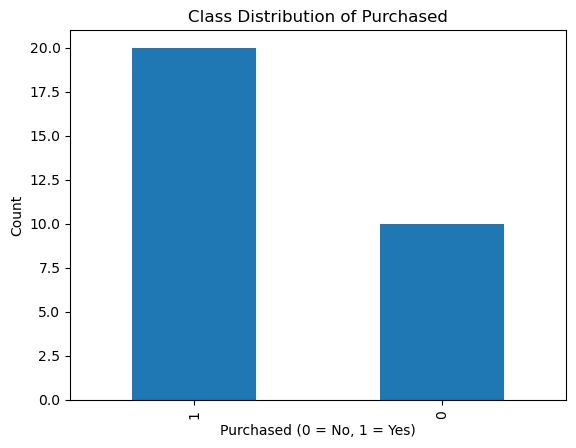

In [26]:
plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Class Distribution of Purchased")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [27]:
# ---------------------------
# Correlation Matrix
# ---------------------------
corr = df.corr()
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
                       Age  AnnualIncome  TimeOnSite  PagesViewed  \
Age              1.000000      0.991124    0.970848     0.977168   
AnnualIncome     0.991124      1.000000    0.980600     0.985666   
TimeOnSite       0.970848      0.980600    1.000000     0.989406   
PagesViewed      0.977168      0.985666    0.989406     1.000000   
DiscountOffered  0.875837      0.886339    0.903178     0.902822   
Purchased        0.769039      0.830048    0.841748     0.831689   

                 DiscountOffered  Purchased  
Age                     0.875837   0.769039  
AnnualIncome            0.886339   0.830048  
TimeOnSite              0.903178   0.841748  
PagesViewed             0.902822   0.831689  
DiscountOffered         1.000000   0.712055  
Purchased               0.712055   1.000000  


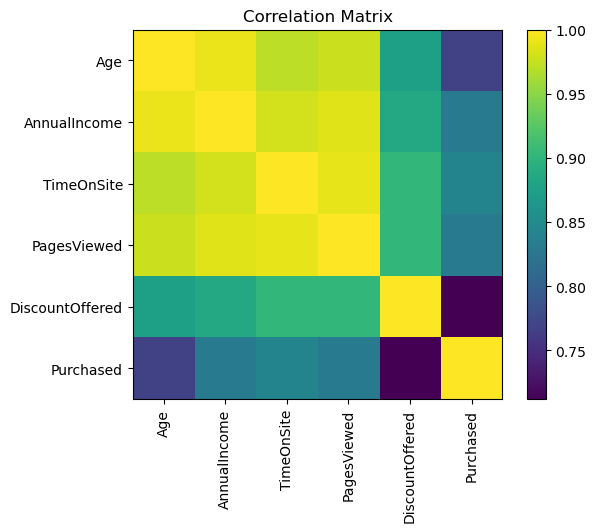

In [28]:
plt.figure()
plt.imshow(corr)
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

In [29]:
# Correlation with target
print("\nCorrelation with Purchased:\n")
print(corr["Purchased"].sort_values(ascending=False))


Correlation with Purchased:

Purchased          1.000000
TimeOnSite         0.841748
PagesViewed        0.831689
AnnualIncome       0.830048
Age                0.769039
DiscountOffered    0.712055
Name: Purchased, dtype: float64


In [30]:
# ============================
# PART B – MODEL BUILDING
# ============================

# 4. Train-Test Split (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [31]:
# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# 6. Train Logistic Regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [33]:
# 7. Logistic Equation
coefficients = model.coef_[0]
intercept = model.intercept_[0]


In [34]:
print("\nLogistic Regression Equation:\n")
equation = f"log(p/(1-p)) = {intercept:.4f}"
for coef, feature in zip(coefficients, X.columns):
    equation += f" + ({coef:.4f} * {feature})"
print(equation)


Logistic Regression Equation:

log(p/(1-p)) = 1.7627 + (0.6395 * Age) + (0.8602 * AnnualIncome) + (0.8215 * TimeOnSite) + (0.7484 * PagesViewed) + (0.5346 * DiscountOffered)


In [36]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients),
    "Odds_Ratio": np.exp(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False)
print("\nFeature Importance:\n")
print(importance)


Feature Importance:

           Feature  Coefficient  Abs_Coefficient  Odds_Ratio
1     AnnualIncome     0.860240         0.860240    2.363728
2       TimeOnSite     0.821519         0.821519    2.273950
3      PagesViewed     0.748446         0.748446    2.113712
0              Age     0.639474         0.639474    1.895484
4  DiscountOffered     0.534560         0.534560    1.706697


In [37]:
# ============================
# PART C – EVALUATION
# ============================

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [38]:
# 8. Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


In [39]:
print("\nModel Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Model Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [41]:
# ---------------------------
# ROC Curve: How well a classification model separates two classes at different threshold values.
# ---------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

AUC Score: 1.0


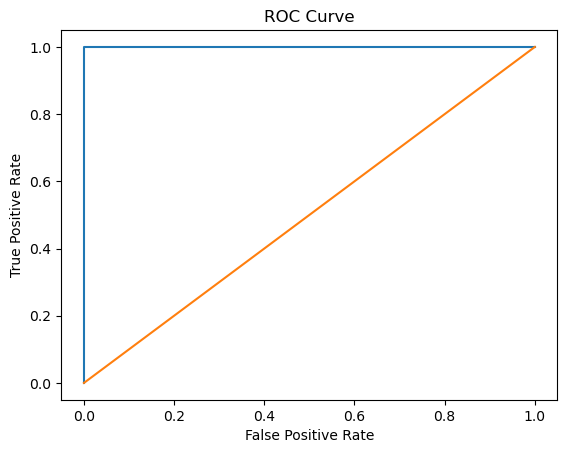

In [42]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [43]:
# ============================
# PART D – INTERPRETATION
# ============================

print("\nINTERPRETATION")

print("\n1. Coefficients Interpretation:")
print("• Positive coefficient → increases purchase probability")
print("• Negative coefficient → decreases purchase probability")


INTERPRETATION

1. Coefficients Interpretation:
• Positive coefficient → increases purchase probability
• Negative coefficient → decreases purchase probability


In [44]:
print("\n2. Odds Ratio for AnnualIncome:")
if "AnnualIncome" in importance["Feature"].values:
    income_odds = importance[importance["Feature"]=="AnnualIncome"]["Odds_Ratio"].values[0]
    print("Odds Ratio (AnnualIncome):", income_odds)
    print("Interpretation: 1 unit increase multiplies odds by", income_odds)

print("\n3. Changing Threshold from 0.5 to 0.7")
y_pred_07 = (y_prob >= 0.7).astype(int)
print("Accuracy (0.7 threshold):", accuracy_score(y_test, y_pred_07))
print("Precision (0.7 threshold):", precision_score(y_test, y_pred_07))
print("Recall (0.7 threshold):", recall_score(y_test, y_pred_07))
print("F1 (0.7 threshold):", f1_score(y_test, y_pred_07))


2. Odds Ratio for AnnualIncome:
Odds Ratio (AnnualIncome): 2.363728491532544
Interpretation: 1 unit increase multiplies odds by 2.363728491532544

3. Changing Threshold from 0.5 to 0.7
Accuracy (0.7 threshold): 1.0
Precision (0.7 threshold): 1.0
Recall (0.7 threshold): 1.0
F1 (0.7 threshold): 1.0


In [45]:
# ============================
# PART E – BUSINESS DECISION
# ============================

print("\nBUSINESS INTERPRETATION")

print("""
• This model helps marketing teams target high-probability buyers.
• It reduces marketing costs by focusing on likely customers.
• False Positive: Marketing cost wasted on non-buyers.
• False Negative: Lost revenue opportunity from real buyers.
• If product margin is high → reduce false negatives (increase recall).
• If marketing budget is tight → reduce false positives (increase precision).
""")


BUSINESS INTERPRETATION

• This model helps marketing teams target high-probability buyers.
• It reduces marketing costs by focusing on likely customers.
• False Positive: Marketing cost wasted on non-buyers.
• False Negative: Lost revenue opportunity from real buyers.
• If product margin is high → reduce false negatives (increase recall).
• If marketing budget is tight → reduce false positives (increase precision).

